In [119]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

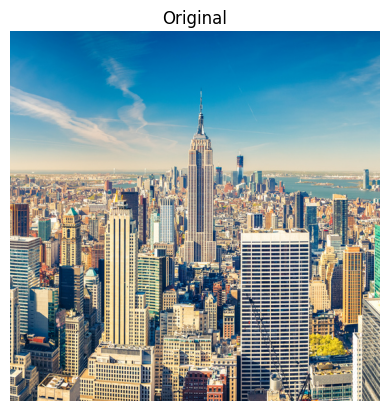

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Original'),
 None)

In [120]:
# blurring (detayı azaltır, noise yi engeller)
img = cv2.imread("NYC.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(),plt.imshow(img), plt.axis('off'), plt.title('Original'),plt.show()

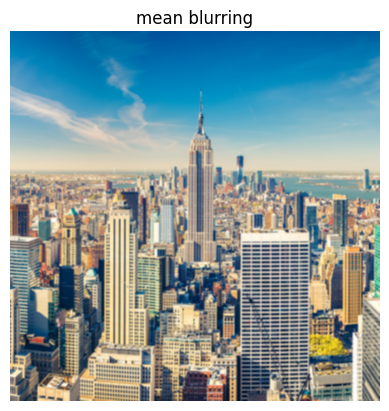

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'mean blurring'),
 None)

In [121]:
# mean blurring
dst2 = cv2.blur(img, ksize=(3, 3))   # dst is destination
plt.figure(), plt.imshow(dst2), plt.axis('off'), plt.title('mean blurring'), plt.show()

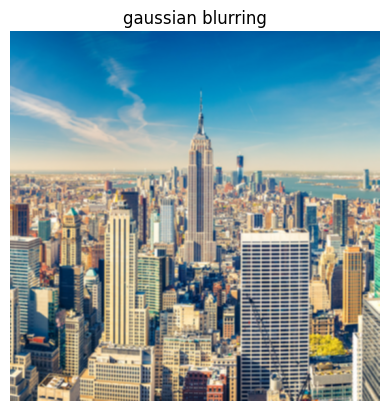

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'gaussian blurring'),
 None)

In [122]:
# gaussian blurring
# sigmaX = çan eğrisinin genişliği(bu pixel çevresinden ne kadar uzağa kadar etkileneyim)
gb = cv2.GaussianBlur(img, ksize=(3, 3), sigmaX=7) # sigamX i 0 yaparsan en uygun sigmayı cv2 hesaplar. sigmaY
# yazmazsak otomatik olarak x yönündekine eşit olur
plt.figure(), plt.imshow(gb),plt.axis('off'), plt.title('gaussian blurring'), plt.show()

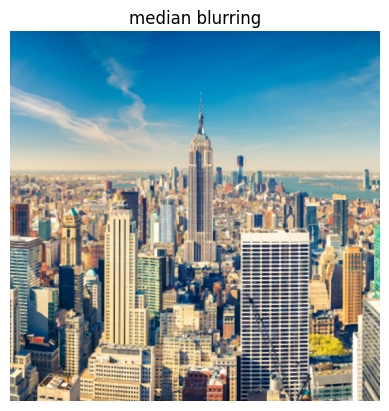

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'median blurring'),
 None)

In [123]:
# median blurring
mb = cv2.medianBlur(img, ksize=3)  # ksize tek sayı olmalı. median old. için
plt.figure(), plt.imshow(mb),plt.axis('off'), plt.title('median blurring'), plt.show()

In [124]:
# add gaussian noise
def gaussian_noise(image):
    row, col, ch = image.shape   # image.shape, (512, 512, 3) gibi sonuç return eder. row, col, channel
    mean = 0
    var = 0.05
    sigma = var ** 0.5

    gauss = np.random.normal(mean, sigma, (row, col, ch)) # gaussian noise
    gauss = gauss.reshape(row, col, ch)
    noisy = image + gauss

    noisy = np.clip(noisy, 0, 1)  # siyahtan siyah, beyazdan beyazları 0 ya da 1 yap. noisy = image + gauss dan dolayı. yoksa en düşük 0 en yüksek 1 dir. alt satırda normalize ettiğimiz için (/255)

    return noisy

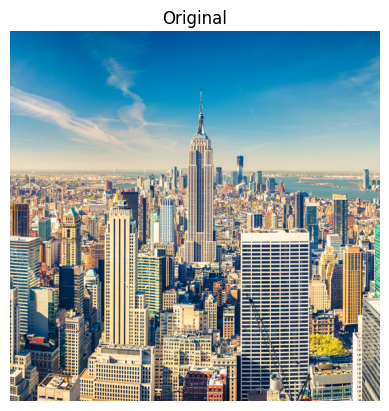

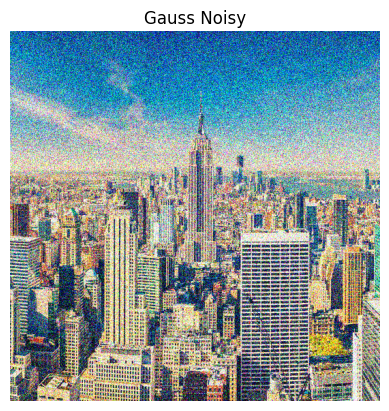

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Gauss Noisy'),
 None)

In [125]:
# normalization. noise yi eklemek için and add noise
img = cv2.imread("NYC.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)/255  # print(img) dersek genlik değerlerinden oluşan matrixi verir
plt.figure(),plt.imshow(img), plt.axis('off'), plt.title('Original'),plt.show()

noised_img = gaussian_noise(img)
plt.figure(),plt.imshow(noised_img), plt.axis('off'), plt.title('Gauss Noisy'),plt.show()


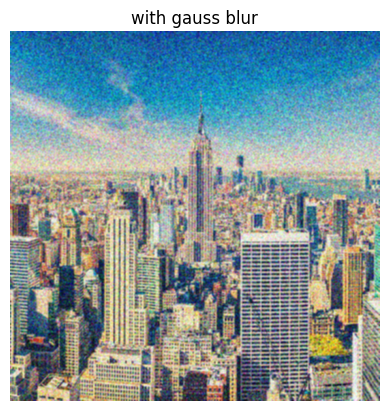

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'with gauss blur'),
 None)

In [129]:
# gauss blur
gb2 = cv2.GaussianBlur(noised_img, ksize=(3, 3), sigmaX=7)
plt.figure(), plt.imshow(gb2),plt.axis('off'), plt.title('with gauss blur'),plt.show()

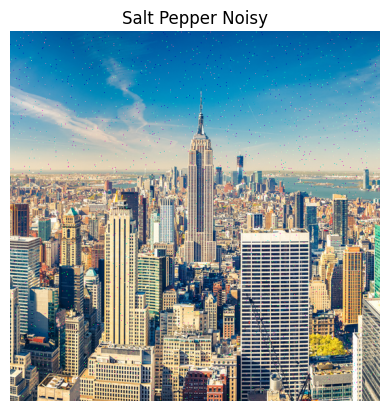

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Salt Pepper Noisy'),
 None)

In [127]:
# add salt pepper noise
def salt_pepper_noise(image):
    row, col, ch = image.shape
    s_vs_p = 0.5
    amount = 0.004

    noisy = np.copy(image)

    # salt
    num_salt = np.ceil(amount * image.size * s_vs_p)  # ceil yuvarlama yapar. 1.1 i 1 e 2.9 u 3 e gibi
    coords = [np.random.randint(0,i - 1, int(num_salt))for i in image.shape] # 1. pixel 0. index old. için i-1
    noisy[tuple(coords)] = 1

    # pepper
    num_pepper = np.ceil(amount * image.size * (1-s_vs_p))
    coords = [np.random.randint(0,i - 1, int(num_pepper))for i in image.shape]
    noisy[tuple(coords)] = 0

    return noisy

sp_image = salt_pepper_noise(img)
plt.figure(),plt.imshow(sp_image), plt.axis('off'), plt.title('Salt Pepper Noisy'),plt.show()

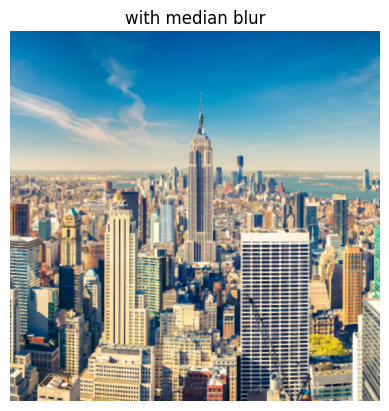

(<Figure size 640x480 with 1 Axes>,
 (np.float64(-0.5), np.float64(542.5), np.float64(542.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'with median blur'),
 None)

In [128]:
# median blur
mb2 = cv2.medianBlur(sp_image.astype(np.float32), ksize=3)
plt.figure(), plt.imshow(mb2),plt.axis('off'), plt.title('with median blur'), plt.show()